# **Project Objective**

The objective of this project is to segment customers based on their purchasing behaviour using RFM analysis and clustering techniques. The identified customer segments can help businesses identify different customer groups and target them with suitable marketing strategies.

# **Project Flow**

                                                                      Raw Data

                                                                         ↓

                                                                      Cleaning

                                                                         ↓

                                                                        EDA

                                                                         ↓

                                                                Feature Engineering (RFM)

                                                                          ↓

                                                                    Preprocessing

                                                                          ↓

                                                                      Clustering

                                                                          ↓

                                                                      Comparison

                                                                         ↓

                                                                Business Recommendations

# **Importing Libraries**

In [123]:
# Data manipulation
import numpy as np
import pandas as pd

# File handling
import zipfile

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage,dendrogram

# Evaluation
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score


# **Loading Dataset**

In [3]:

# Extract archive
with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

# Read second sheet
df = pd.read_excel(
    "/content/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **Understanding the Dataset**

**Dimensions of the Dataset**

In [4]:
df.shape

(541910, 8)

* Number of rows: 5,41,910
* Number of columns: 8

**Basic information about columns**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Statiscal summary of the numerical columns**

In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


Observations:
* Both the Quantity and Price columns contain negative values (minimum Quantity = -80,995 and minimum Price = -11,062.06), indicating the presence of abnormal transactions that require further investigation before analysis.
* The transaction dates range from December 2010 to December 2011, providing approximately one year of customer purchase history, which is suitable for customer segmentation.

In [7]:
print('No. of transactions having negative quantities:',(df['Quantity']<0).sum())

No. of transactions having negative quantities: 10624


In [8]:

df[df['Quantity']<0].head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


* It seems most negative quantities are associated with invoice starting with 'C' which are cancelled invoices.

In [9]:
# Negative quantities with cancelled invoices
((df["Quantity"] < 0) & (df["Invoice"].astype(str).str.startswith("C"))).sum()

np.int64(9288)

In [10]:
# checking if Customer ID is missing
df[(df["Quantity"] < 0) & (df["Invoice"].astype(str).str.startswith("C"))]['Customer ID'].isna().value_counts()

,count
Customer ID,
False,8905
True,383


In [11]:
# Negative quantities without cancelled invoices
((df["Quantity"] < 0) & (~df["Invoice"].astype(str).str.startswith("C"))).sum()

np.int64(1336)

In [12]:
# checking if Customer ID is missing
df[((df["Quantity"] < 0) & (~df["Invoice"].astype(str).str.startswith("C")))]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536910,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


In [13]:
df[
    (df["Quantity"] < 0) &
    (~df["Invoice"].astype(str).str.startswith("C"))
]["Customer ID"].isna().value_counts()

,count
Customer ID,
True,1336


* Total number of negative quantity transactions: 10624
* Negative quantity transactions with cancelled invoice: 9288
* Negative quantity transactions with cancelled invoice and missing Customer ID: 383
* Negative quantity transactions without cancelled invoice: 1336
* All the negative quantity transactions without cancelled invoice have no Customer ID.


In [14]:
(df['Price']<0).sum()

np.int64(2)

In [15]:
df[df['Price']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


* There are only two transactions having negative Price values, both have no Customer ID.

**Checking unique values in important categorical columns**

In [16]:
print('Number of unique countries:',df['Country'].nunique())

Number of unique countries: 38


In [17]:
print('Unique countries:\n',df['Country'].unique())

Unique countries:
 ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Bahrain' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


In [18]:
print('Number of unique customers:',df['Customer ID'].nunique())

Number of unique customers: 4372



**Missing value inspection**

In [19]:

df.isna().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [20]:
print('Total number of missing values in the Dataset:',df.isna().sum().sum())

Total number of missing values in the Dataset: 136534


**Inspecting duplicates**

In [21]:
print('Total number of duplicated rows:',df.duplicated().sum())

Total number of duplicated rows: 5268


In [22]:
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


# **Data Cleaning**

**Handling missing Customer IDs**
* We cannot assign transactions to a customer without a Customer ID.
* Since this is a customer segmentation project, these rows cannot contribute to clustering
* Removing all missing Customer ID transactions will remove all the negative price transactions and transactions with negative quantity and uncancelled invoice.

In [23]:
df.dropna(subset=['Customer ID'],inplace=True)

In [24]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [111]:
print('No. of transactions with Missing Description:',df['Description'].isna().sum())

No. of transactions with Missing Description: 0


* Removing missing Customer IDs also removed missing Descriptions.

In [25]:
df[df['Invoice'].astype(str).str.startswith('C')].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [26]:
print('No. of negative quantity transactions:',(df['Quantity']<0).sum())
print('No. of cancelled invoice transations:',(df['Invoice'].astype(str).str.startswith('C')).sum())
print('No. transactions with negative quatity and cancelled invoice:',((df['Invoice'].astype(str).str.startswith('C'))&(df['Quantity']<0)).sum())

No. of negative quantity transactions: 8905
No. of cancelled invoice transations: 8905
No. transactions with negative quatity and cancelled invoice: 8905


* After removing transactions with missing Customer IDs, majority of negative quantity transactions were also removed alongwith it. All remaining negative quantities corresponded to cancelled invoices (8,905 transactions) now.

In [27]:
print('No. of unique customers after preprocessing:',df['Customer ID'].nunique())

No. of unique customers after preprocessing: 4372


**Handling cancelled invoice:**
* Cancelled transactions do not represent completed purchases and therefore do not reflect customer buying patterns. Including them would distort purchase frequency, monetary value, and other customer-level features used for segmentation. Hence, we remove all cancelled invoices.

In [28]:
df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [29]:
(df['Invoice'].astype(str).str.startswith('C')).sum()

np.int64(0)

* Since all remaining negative quantities corresponded to cancelled invoices . Therefore, removing cancelled invoices also eliminated all remaining negative-quantity transactions.

**Handling Duplicates:**


In [30]:
df=df.drop_duplicates()

In [31]:
df.reset_index(drop=True, inplace=True)

In [32]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
392728,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
392729,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
392730,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
392731,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


* Exact duplicate records were removed to eliminate redundant observations and ensure that each transaction is represented only once.

Data Cleaning Summary:
* Removed Missing Customer ID transacrions
* Removed Cancelled invoice transactions
* Removed Duplicated rows
* Negative quantities removed
* Negative price removed

Final Dataset size: 3,92,733 rows

# **Exploratory Data Analysis**

**Countries with most transactions**

Text(0.5, 1.0, 'Transactions by Country')

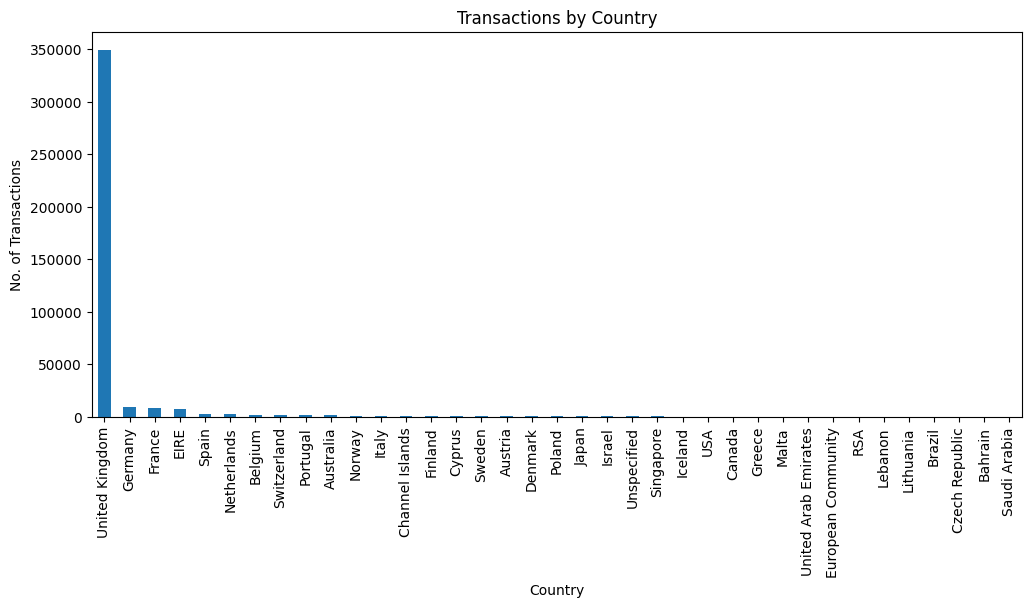

In [33]:
plt.figure(figsize=(12,5))
df['Country'].value_counts().plot(kind='bar')
plt.ylabel('No. of Transactions')
plt.title('Transactions by Country')

* The majority of transactions originated from the United Kingdom.

**Countries generating highest revenue**

In [34]:
df['Revenue']=df['Quantity']*df['Price']

* Revenue is calculated for each transaction and later aggregated to obtain each customer's total spending (Monetary value).

Text(0.5, 1.0, 'Revenue by Country')

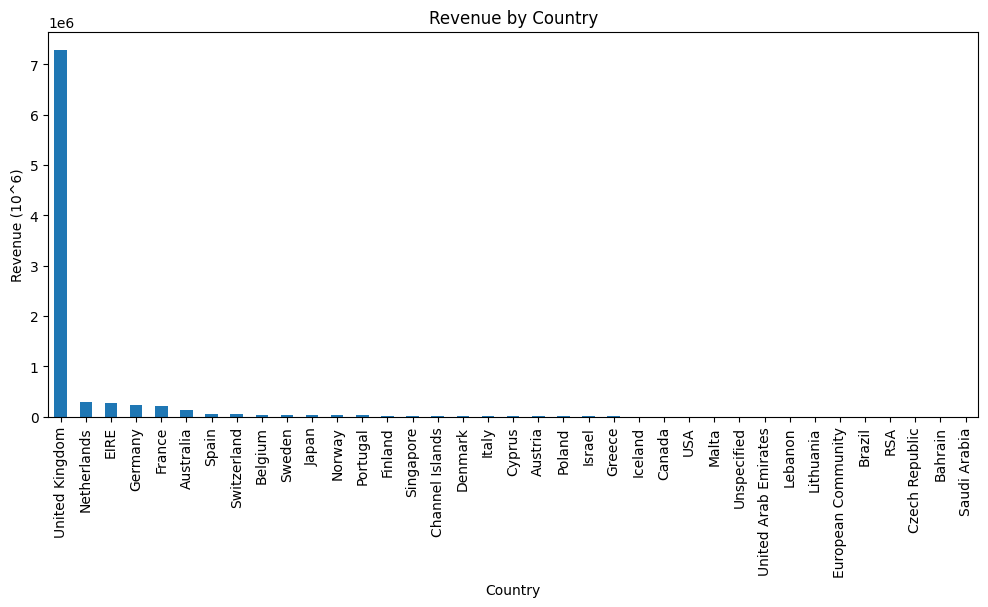

In [35]:
plt.figure(figsize=(12,5))
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Revenue (10^6)')
plt.title('Revenue by Country')

* United Kingdom generates the highest revenue by large margin.

**Most sold products by quantity**

In [36]:
print('===========Top 10 most sold products===========')
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

===========Top 10 most sold products===========


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


**Revenue by Month**

In [37]:
df['YearMonth']=df['InvoiceDate'].dt.to_period('M')

Text(0.5, 1.0, 'Monthly Revenue')

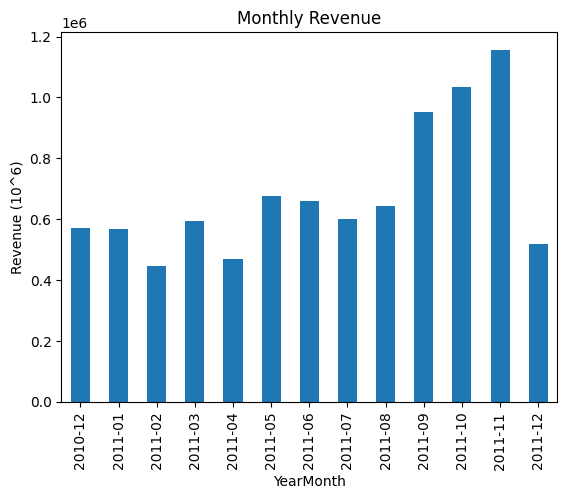

In [38]:
df.groupby('YearMonth')['Revenue'].sum().plot(kind='bar')
plt.xlabel('YearMonth')
plt.ylabel('Revenue (10^6)')
plt.title('Monthly Revenue')

* Revenue remained similar across the months except September to November 2011 which witnessed high revenues relatively. The lower revenue in December is expected since the dataset includes only the first nine days of the month.


**Customer purchase frequency**

In [39]:
df.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False).head(15)

,Invoice
Customer ID,
12748.0,210
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,74
16029.0,63


* There are small number of customers who purchase more than others indicating presence of highly active or loyal customers. Purchasing behaviour is not uniform.

**Revenue by Customers**

In [40]:
df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(15)

,Revenue
Customer ID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


* There are few customers generating higher revenue than others indicating that some high-value customers are important for business revenue.

Some customers (e.g., 14911, 18102, 16029, 15311, 13089) appear in both lists. This suggests that customers who purchase frequently often generate high revenue, although purchase frequency alone does not completely determine customer value.

# **RFM Analysis**

RFM (Recency, Frequency, Monetary) analysis is a widely used technique for understanding customer purchasing behaviour.

* Recency measures how recently a customer made a purchase.
* Frequency measures how often a customer makes purchases.
* Monetary measures the total amount spent by a customer.

Since the original dataset is at the transaction level, it is not suitable for customer segmentation. Therefore, the data was aggregated to the customer level using RFM features. These three features effectively summarize each customer's purchasing behaviour and are widely used for customer segmentation and targeted marketing.

In [41]:
reference_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [42]:
rfm=df.groupby('Customer ID').agg(
    {
        'InvoiceDate':lambda x: (reference_date-x.max()).days,
        'Invoice':'nunique',
        'Revenue':'sum'
    }
)

In [43]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [44]:
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


# **Post-RFM EDA**

**Size of Dataset**

In [112]:
rfm.shape

(4339, 3)

* There are 4339 unique customers and RFM dataset shows their Recency, Frequency and Monetary values.

**Basic column info**

In [45]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4339 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4339 non-null   int64  
 1   Frequency  4339 non-null   int64  
 2   Monetary   4339 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


**Statistical Summary**

In [46]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.220072
std,100.009747,7.705493,8984.247808
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000


**Histogram plots to examine Distribution**

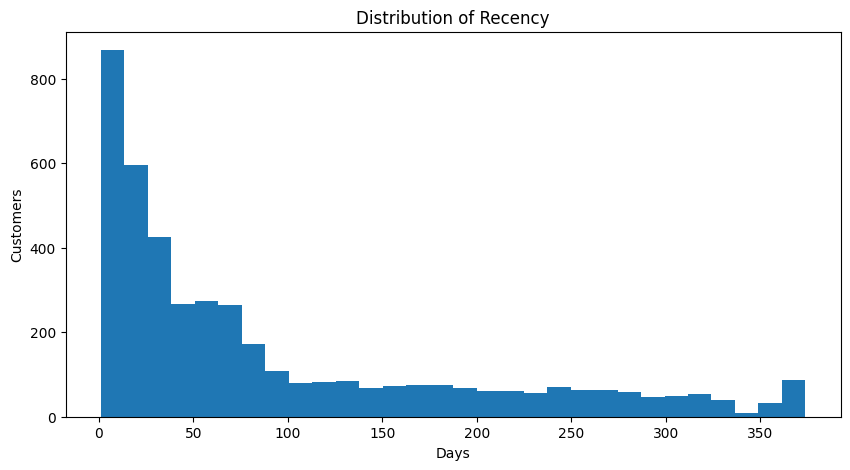

In [47]:
plt.figure(figsize=(10,5))
plt.hist(rfm['Recency'],bins=30)
plt.xlabel('Days')
plt.ylabel('Customers')
plt.title('Distribution of Recency')
plt.show()

* The recency distribution is right skewed, with a larger number of customers making recent purchases while relatively small number of customers remained inactive for a long period.

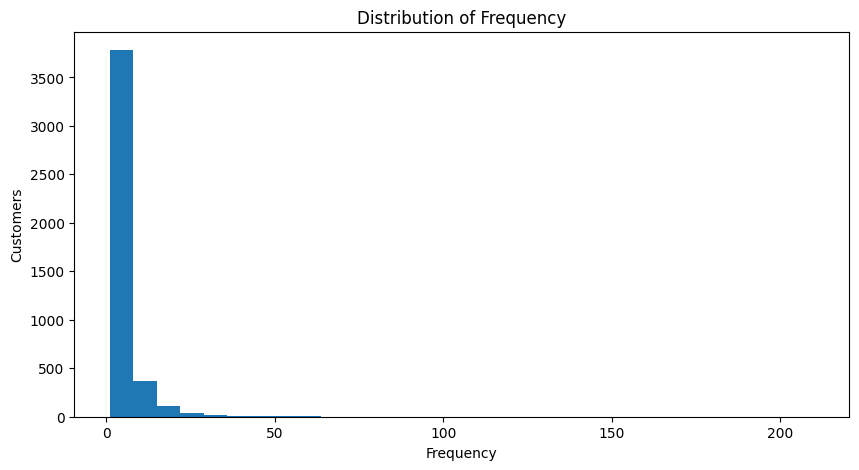

In [48]:
plt.figure(figsize=(10,5))
plt.hist(rfm['Frequency'],bins=30)
plt.xlabel('Frequency')
plt.ylabel('Customers')
plt.title('Distribution of Frequency')
plt.show()

* The Frequency distribution is highly righly skewed. Most customers made only a few purchases, while a small number of customers purchase very frequently indicating presence of loyal or highly active customers.

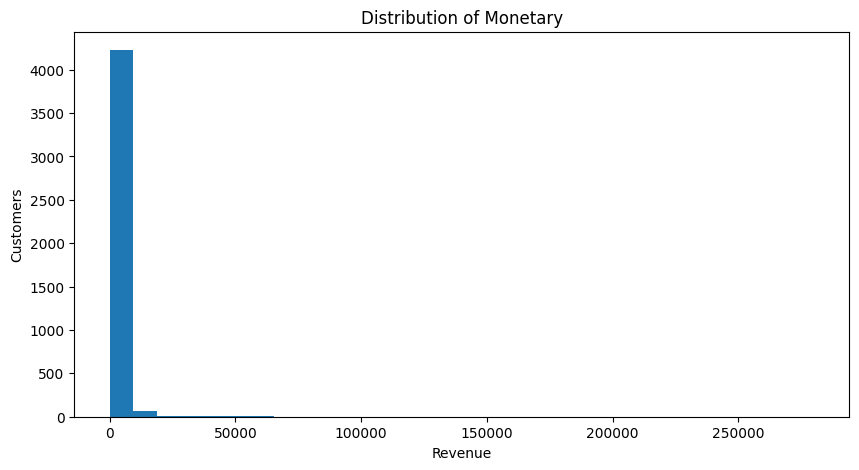

In [49]:
plt.figure(figsize=(10,5))
plt.hist(rfm['Monetary'],bins=30)
plt.xlabel('Revenue')
plt.ylabel('Customers')
plt.title('Distribution of Monetary')
plt.show()

* Monetary distribution is highly skewed. Most customers generate very low revenue while a few customers account for very high revenue, indicating presence of high-value customers.

**Skewness**

In [50]:
print('Skewness of Recency:',round(rfm['Recency'].skew(),2))
print('Skewness of Frequency:',round(rfm['Frequency'].skew(),2))
print('Skewness of Monetary:',round(rfm['Monetary'].skew(),2))

Skewness of Recency: 1.25
Skewness of Frequency: 12.1
Skewness of Monetary: 19.34


**Boxplots**

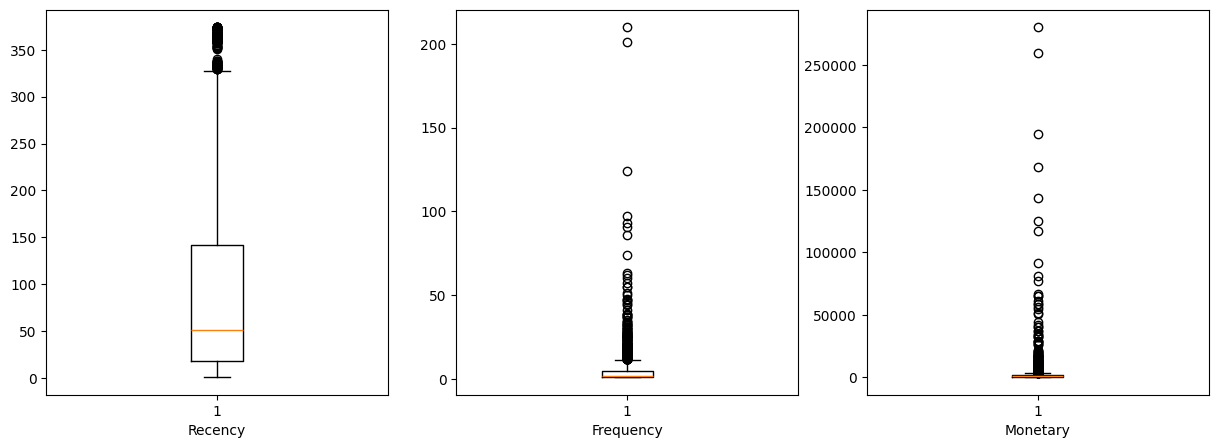

In [51]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.boxplot(rfm['Recency'])
plt.xlabel('Recency')

plt.subplot(1,3,2)
plt.boxplot(rfm['Frequency'])
plt.xlabel('Frequency')

plt.subplot(1,3,3)
plt.boxplot(rfm['Monetary'])
plt.xlabel('Monetary')

plt.show()

* Frequency and Monetary features have a high no. of outliers while Recency has relatively low no. of outliers.

**Log Transformation**

In [52]:
rfm_log=rfm.copy()

rfm_log['Recency']=np.log1p(rfm_log['Recency'])
rfm_log['Frequency']=np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']=np.log1p(rfm_log['Monetary'])

In [53]:
log_effect=pd.DataFrame({
    'Feature':['Recency','Frequency','Monetary'],
    'Before':rfm[['Recency','Frequency','Monetary']].skew(),
    'After':rfm_log[['Recency','Frequency','Monetary']].skew()
})
log_effect.set_index('Feature')


,Before,After
Feature,,
Recency,1.246357,-0.378677
Frequency,12.100028,1.208917
Monetary,19.341405,0.363716


**Post-Log Transformation Distribution**

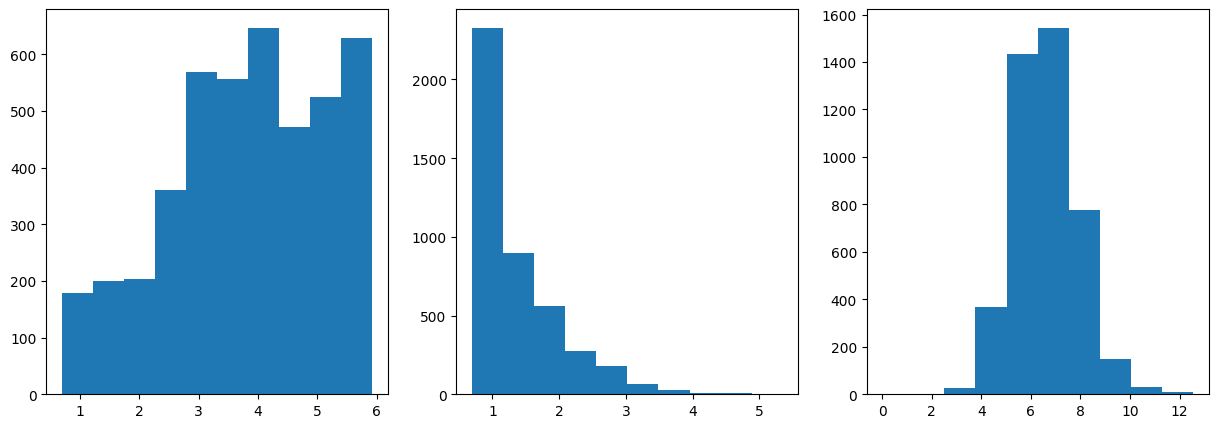

In [54]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(rfm_log['Recency'])

plt.subplot(1,3,2)
plt.hist(rfm_log['Frequency'])

plt.subplot(1,3,3)
plt.hist(rfm_log['Monetary'])

plt.show()

* The RFM features had very high skewness, particularly Frequency (12.10) and Monetary (19.34). Since K-Means relies on Euclidean distance and is sensitive to highly skewed data, a log transformation (log1p) was applied. The transformation substantially reduced the skewness to -0.38, 1.21 and 0.36 respectively, producing distributions that are more suitable for clustering.

**Correlation**

In [55]:
corr_table=rfm_log.corr(numeric_only=True)
corr_table

,Recency,Frequency,Monetary
Recency,1.000000,-0.569796,-0.481383
Frequency,-0.569796,1.000000,0.806628
Monetary,-0.481383,0.806628,1.000000


<Axes: >

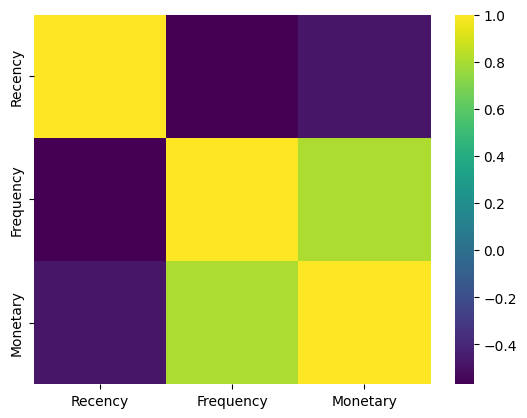

In [56]:
sns.heatmap(corr_table,cmap='viridis')

**Standardization**

In [57]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_log)

In [58]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)
rfm_scaled

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,1.462236,-0.955013,3.697681
12347.0,-2.038611,1.074523,1.411815
12348.0,0.373310,0.386437,0.719042
12349.0,-0.622914,-0.955013,0.701358
12350.0,1.424800,-0.955013,-0.611452
...,...,...,...
18280.0,1.343773,-0.955013,-1.097554
18281.0,1.024977,-0.955013,-1.729258
18282.0,-1.218789,-0.361412,-1.108759


In [59]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4339.00,4339.00,4339.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-5.22
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.06
75%,0.85,0.65,0.66
max,1.56,5.87,4.72


* Standardization was applied after the log transformation because clustering was performed on the transformed features.

# **KMeans**

**Elbow method to decide k**

In [61]:
wcss=[]
for i in range(1,21):
  km=KMeans(n_clusters=i,random_state=42,n_init='auto')
  km.fit(rfm_scaled)
  wcss.append(km.inertia_)

In [63]:
fig=px.line(x=range(1,21),y=wcss,markers='o',
            labels={
                'x':'Number of Clusters(k)',
                'y':'WCSS'
            },
            title='WCSS vs Number of Clusters'
            )
fig.show()

**Silhouette score to decide k**

In [65]:
silhouette_scores=[]
for k in range(2,11):
  km=KMeans(n_clusters=k,random_state=42,n_init='auto')
  labels=km.fit_predict(rfm_scaled)
  score=silhouette_score(rfm_scaled,labels)
  silhouette_scores.append(score)

In [66]:
fig=px.line(x=range(2,11),y=silhouette_scores,markers='o',
            labels={
                'x':'Number of Clusters(k)',
                'y':'Silhouette Score'
            },
            title="Silhouette Score vs Number of Clusters"
          )
fig.show()


* The Elbow Method suggested k = 4 because the WCSS curve started flattening after 4 clusters.

* The Silhouette Score was highest for k = 2, indicating the best cluster separation.

* Therefore, k = 2 and k = 4 are selected as candidate values to investigate further.

**For k=2**

In [67]:
kmeans_2=KMeans(n_clusters=2,random_state=42,n_init='auto')
labels_2=kmeans_2.fit_predict(rfm_scaled)

In [68]:
rfm_k2=rfm.copy()
rfm_k2['Cluster']=labels_2
rfm_k2

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,0
...,...,...,...,...
18280.0,278,1,180.60,0
18281.0,181,1,80.82,0
18282.0,8,2,178.05,0


**Cluster Summary**

In [69]:
rfm_k2.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
).round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,2678,133.94,1.68,496.57
1,1661,25.74,8.46,4549.91


Cluster 0 represents inactive,infrequent and low-spending customers

cluster 1 represents active,frequent and high spending customers



**For k=4**

In [70]:
kmeans_4=KMeans(n_clusters=4,random_state=42,n_init='auto')
labels_4=kmeans_4.fit_predict(rfm_scaled)

In [71]:
rfm_k4=rfm.copy()
rfm_k4['Cluster']=labels_4
rfm_k4

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,3
...,...,...,...,...
18280.0,278,1,180.60,3
18281.0,181,1,80.82,3
18282.0,8,2,178.05,0


**Cluster Summary**

In [72]:
rfm_k4.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
).round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,847,19.13,2.07,529.49
1,730,12.11,13.56,7942.68
2,1191,71.13,4.05,1772.05
3,1571,185.66,1.32,337.41


Cluster 1: Very recent,very frequent purchasers and very high spending. These are highest-value customers.

Cluster 3: Customers who have not purchased for a long time and have the lowest purchase frequency and spending, indicating a high likelihood of churn.

Cluster 0 : These customers purchased recently but have low purchase frequency and low spending.

Cluster 2: Customers with moderate recency, purchase frequency, and spending, representing a stable and consistent customer base.



**Choosing between k=2 and k=4**

* k = 2: Highest Silhouette Score (better cluster separation), but produced only two broad customer groups: high-value and low-value customers. Thus, there are only two categories broadly, Good customers vs Poor customers , that is useful but not very actionable as it does not provide much scope for designing targeted strategies.
* k = 4: Slightly lower Silhouette Score, but the Elbow Method also suggested this value and it generated four distinct, interpretable, and business-relevant customer segments. Provides greater scope for designing target strategies.
* Final Selection: k = 4 was chosen because it provides a more informative and actionable customer segmentation while maintaining acceptable clustering performance.

**Final KMeans clustering with k=4**

In [73]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
labels_km = kmeans.fit_predict(rfm_scaled)

rfm_km = rfm.copy()
rfm_km["Cluster"] = labels

In [74]:

rfm_km

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,5
12347.0,2,7,4310.00,7
12348.0,75,4,1797.24,5
12349.0,19,1,1757.55,4
12350.0,310,1,334.40,2
...,...,...,...,...
18280.0,278,1,180.60,9
18281.0,181,1,80.82,9
18282.0,8,2,178.05,0


**PCA for visualizing clusters**

In [75]:
pca=PCA(n_components=2,random_state=42)
rfm_pca=pca.fit_transform(rfm_scaled)
rfm_pca=pd.DataFrame(rfm_pca,columns=['PC1','PC2'])

In [76]:
rfm_pca_km=rfm_pca.copy()
rfm_pca_km["Cluster"] = labels_km
rfm_pca_km


,PC1,PC2,Cluster
0,0.866342,2.697308,2
1,2.549773,-0.803056,1
2,0.476748,0.748052,2
3,0.146498,-0.453021,0
4,-1.684411,0.681291,3
...,...,...,...
4334,-1.932848,0.388652,3
4335,-2.146437,-0.172935,3
4336,-0.261001,-1.638972,0
4337,2.685053,-0.465736,1


In [77]:
fig = px.scatter(
    rfm_pca_km,
    x="PC1",
    y="PC2",
    color="Cluster",
    title="Customer Segments using K-Means (PCA Visualization)"
)


fig.show()

In [78]:
print(pca.explained_variance_ratio_)

[0.7498258  0.18846458]


In [125]:
print('Explained Variance:')

print('PC1:',round(pca.explained_variance_ratio_[0]*100,2))
print('PC2:',round(pca.explained_variance_ratio_[1]*100,2))
print('Total EXplained Variance:',round(sum(pca.explained_variance_ratio_)*100,2))

Explained Variance:
PC1: 74.98
PC2: 18.85
Total EXplained Variance: 93.83


* The first two principal components explain ~94% of the variance in the data. Therefore, a two-dimensional PCA plot provides a good visual representation of the customer clusters.

**Metric scores of KMeans**

In [80]:
print('Silhouette Score of KMeans:',round(silhouette_score(rfm_scaled,labels_km),2))
print('Davies Bouldin Index of KMeans:',round(davies_bouldin_score(rfm_scaled,labels_km),2))
print('Calimski Harabasz Index of KMeans:',round(calinski_harabasz_score(rfm_scaled,labels_km),2))

Silhouette Score of KMeans: 0.34
Davies Bouldin Index of KMeans: 1.01
Calimski Harabasz Index of KMeans: 3313.12


# **Hierarchical Agglomerative Clustering**

In [82]:
linkage_matrix=linkage(rfm_scaled,method='ward')

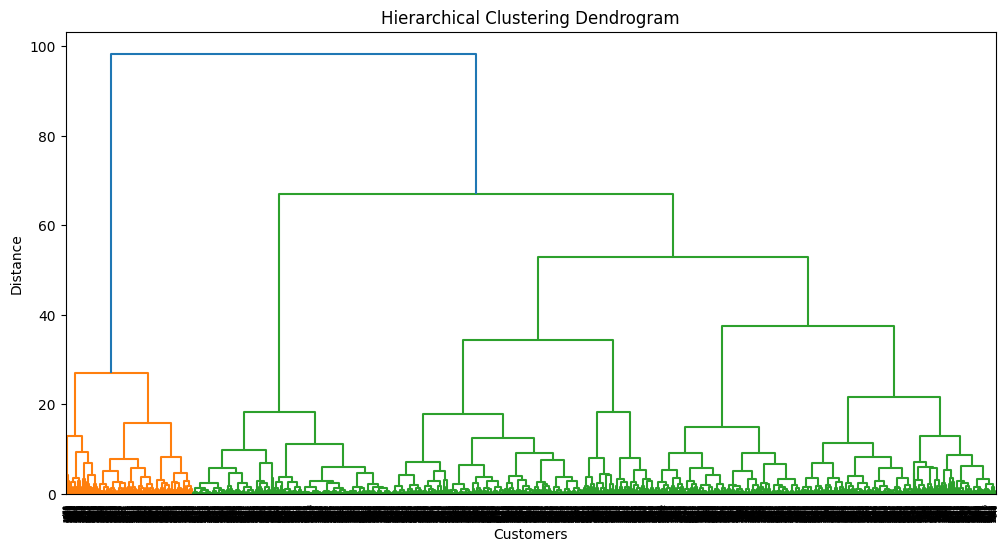

In [83]:
plt.figure(figsize=(12,6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

* The dendrogram shows large jumps in linkage distance around 67 and 98. A cut at approximately 35–40 results in four well-defined clusters, which is also consistent with the number of clusters selected using K-Means.
* For Hierarchical Clustering , Final k=4.

**Agglomerative Clusterimg with k=4**

In [85]:
from sklearn.cluster import AgglomerativeClustering

hc=AgglomerativeClustering(n_clusters=4,linkage='ward')
labels_hc=hc.fit_predict(rfm_scaled)

In [86]:
rfm_hc=rfm.copy()

rfm_hc['Cluster']=labels_hc
rfm_hc

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,2
...,...,...,...,...
18280.0,278,1,180.60,2
18281.0,181,1,80.82,2
18282.0,8,2,178.05,1


**Cluster Summary**

In [87]:
rfm_hc.groupby('Cluster').agg(
  Customers=('Cluster','count'),
    Recency=('Recency','mean'),
    Frequency=('Frequency','mean'),
    Monetary=('Monetary','mean')
).round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,1590,80.93,3.88,1851.21
1,1227,35.89,1.78,465.24
2,930,239.15,1.25,255.49
3,592,10.66,15.23,8674.58


* Cluster 3 consisted of highly active customers with the highest purchase frequency and monetary value.
* Cluster 2 represented inactive customers with the highest recency and the lowest purchase frequency and spending.
* Cluster 1 contained relatively recent customers with low purchase frequency and spending.
* Cluster 0 consisted of customers with moderate recency, purchase frequency, and spending.




Overall, Hierarchical Clustering identified four customer groups with distinct purchasing behaviours, including inactive customers, highly active customers, and two intermediate customer segments.

**PCA visualization**

In [88]:
rfm_pca_hc=rfm_pca.copy()
rfm_pca_hc['Cluster']=labels_hc
rfm_pca_hc

,PC1,PC2,Cluster
0,0.866342,2.697308,0
1,2.549773,-0.803056,3
2,0.476748,0.748052,0
3,0.146498,-0.453021,0
4,-1.684411,0.681291,2
...,...,...,...
4334,-1.932848,0.388652,2
4335,-2.146437,-0.172935,2
4336,-0.261001,-1.638972,1
4337,2.685053,-0.465736,3


In [89]:
fig=px.scatter(
    rfm_pca_hc,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='Customer Segmentation using Hierarchical Clustering'
)
fig.show()

**Metric Scores of Hierarchical Clustering**

In [90]:
print('Slihouette Score of Hierarchical Clustering:',round(silhouette_score(rfm_scaled,labels_hc),2))
print('Davies Bouldin Index of Hierarchical Clustering:',round(davies_bouldin_score(rfm_scaled,labels_hc),2))
print('Calinski Harabasz Index of Hierarchical Clustering:',round(calinski_harabasz_score(rfm_scaled,labels_hc),2))

Slihouette Score of Hierarchical Clustering: 0.28
Davies Bouldin Index of Hierarchical Clustering: 1.13
Calinski Harabasz Index of Hierarchical Clustering: 2686.36


# **DBSCAN**

**Choosing min_samples**

In [92]:
min_samples=6

* min_samples was selected as 6 following the commom heuristic of choosing min_samples as twice the number of dimensions.

**Choosing eps**

In [114]:
neighbors=NearestNeighbors(n_neighbors=6)
neighbors_fit=neighbors.fit(rfm_scaled)

distances,indices=neighbors_fit.kneighbors(rfm_scaled)

In [115]:
distances,distances.shape

(array([[0.        , 1.13085192, 1.22079392, 1.76455853, 2.12138271,
         2.17336825],
        [0.        , 0.23252204, 0.23269116, 0.27054817, 0.32921173,
         0.334157  ],
        [0.        , 0.10088505, 0.10509857, 0.12005651, 0.12959756,
         0.15060436],
        ...,
        [0.        , 0.09041496, 0.17132146, 0.19900582, 0.21566657,
         0.22073239],
        [0.        , 0.21597735, 0.2987873 , 0.33473244, 0.34919014,
         0.37334621],
        [0.        , 0.01728266, 0.09742632, 0.13245661, 0.19442693,
         0.19847919]]),
 (4339, 6))

In [116]:
print('6th nearest distance from every observations:',distances[:,5])

6th nearest distance from every observations: [2.17336825 0.334157   0.15060436 ... 0.22073239 0.37334621 0.19847919]


In [117]:
distances=np.sort(distances[:,5])

In [119]:
print('All the 6th nearest distances in ascending order:',distances)

All the 6th nearest distances in ascending order: [0.01578323 0.01627616 0.0179562  ... 2.17336825 2.55157309 2.7780195 ]


**Plotting all the 6th nearest distances**

In [98]:
fig=px.line(x=range(len(distances)),y=distances,
            labels={
                'x':'Points sorted by distance',
                'y':'6th nearest neighbor distance'
            },
            title='k-distance graph'
    )
fig.show()

* Elbow of the graph is around 0.5 so choosing eps=0.5

**Fitting DBSCAN**

In [99]:
dbscan=DBSCAN(eps=0.50,min_samples=6)
labels_db=dbscan.fit_predict(rfm_scaled)

In [100]:
print('Unique Clusters are:',np.unique(labels_db))

Unique Clusters are: [-1  0  1  2]


In [101]:
n_clusters=len(set(labels_db))-(1 if -1 in labels_db else 0)
print('Number of non-noise clusters:',n_clusters)

Number of non-noise clusters: 3


In [102]:
noise=list(labels_db).count(-1)
print('Number of noise points:',noise)

Number of noise points: 65


**Labeled  dataset with DBSCAN clustering**

In [103]:
rfm_db=rfm.copy()

rfm_db['Cluster']=labels_db

rfm_db

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,-1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,1
...,...,...,...,...
18280.0,278,1,180.60,1
18281.0,181,1,80.82,1
18282.0,8,2,178.05,0


**Cluster Summary table**

In [104]:
rfm_db.groupby('Cluster').agg(
    Customers=('Cluster','count'),
    Recency=('Recency','mean'),
    Frequency=('Frequency','mean'),
    Monetary=('Monetary','mean')
)


,Customers,Recency,Frequency,Monetary
Cluster,,,,
-1,65,53.907692,31.830769,42147.149846
0,2788,59.199785,5.359397,1994.828380
1,1484,156.917116,1.000000,354.319913
2,2,9.500000,20.500000,30134.940000


* Cluster 0 contained the majority of customers with moderate purchasing behaviour.
* Cluster 1 consisted of inactive customers with low purchase frequency and spending.
* Cluster 2 contained only two extremely high-value customers.
* it identified 65 customers as noise, representing customers that did not belong to any dense cluster.

Overall, DBSCAN identified one dominant customer cluster along with a small inactive cluster, a tiny cluster of high-value customers, and several noise points, resulting in a less balanced and less interpretable segmentation than the previous clustering methods.

**PCA Visulalization**

In [105]:
rfm_pca_db=rfm_pca.copy()
rfm_pca_db['Cluster']=labels_db
rfm_pca_db

,PC1,PC2,Cluster
0,0.866342,2.697308,-1
1,2.549773,-0.803056,0
2,0.476748,0.748052,0
3,0.146498,-0.453021,1
4,-1.684411,0.681291,1
...,...,...,...
4334,-1.932848,0.388652,1
4335,-2.146437,-0.172935,1
4336,-0.261001,-1.638972,0
4337,2.685053,-0.465736,0


In [106]:
fig=px.scatter(
    rfm_pca_db,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='Customer Segmentation using DBSCAN'
)
fig.show()

**Metrics**

In [107]:
print('Silhoette Score of DBSCAN:',round(silhouette_score(rfm_scaled,labels_db),2))
print('Davies Bouldin Score of DBSCAN:',round(davies_bouldin_score(rfm_scaled,labels_db),2))
print('Calinski Harabasz Score of DBSCAN:',round(calinski_harabasz_score(rfm_scaled,labels_db),2))

Silhoette Score of DBSCAN: 0.21
Davies Bouldin Score of DBSCAN: 2.02
Calinski Harabasz Score of DBSCAN: 830.95


# **Comparison: KMeans vs Hierarchical vs DBSCAN clustering**

**Metric comparison**

In [108]:
metrics_comparison_table=pd.DataFrame({
    'Metric':['Number of Clusters','Noise Points','Silhouette Score','Davies Bouldin-Index','Calinski-Harabasz Index'],
    'KMeans':[np.unique(labels_km).size,0,silhouette_score(rfm_scaled,labels_km),davies_bouldin_score(rfm_scaled,labels_km),calinski_harabasz_score(rfm_scaled,labels_km)],
    'Hierarchical':[np.unique(labels_hc).size,0,silhouette_score(rfm_scaled,labels_hc),davies_bouldin_score(rfm_scaled,labels_hc),calinski_harabasz_score(rfm_scaled,labels_hc)],
    'DBSCAN':[n_clusters,noise,silhouette_score(rfm_scaled,labels_db),davies_bouldin_score(rfm_scaled,labels_db),calinski_harabasz_score(rfm_scaled,labels_db)]

}).round(2)
metrics_comparison_table.set_index('Metric')

,KMeans,Hierarchical,DBSCAN
Metric,,,
Number of Clusters,4.00,4.00,3.00
Noise Points,0.00,0.00,65.00
Silhouette Score,0.34,0.28,0.21
Davies Bouldin-Index,1.01,1.13,2.02
Calinski-Harabasz Index,3313.12,2686.36,830.95


* The higher the silhouette score and calinski-harabasz index and the lower the davies-bouldin index the better the algorithm.




**Business perspective comparison**

| Algorithm                   | Business Perspective                                                                                                                    |
| --------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **K-Means**                 | Produced well-balanced, well-separated, highly interpretable and actionable customer segments.                                          |
| **Hierarchical Clustering** | Produced meaningful and interpretable customer segments with good separation.                                                           |
| **DBSCAN**                  | Produced one dominant cluster along with small clusters and noise points, making the segmentation less balanced and less interpretable. |


# **Final Model Selection:**

Based on the evaluation metrics and business perspective, **K-Means was selected as the final clustering algorithm**. It achieved the highest Silhouette Score and Calinski–Harabasz Index, the lowest Davies–Bouldin Index, and produced four well-balanced and interpretable customer segments suitable for customer segmentation

# **Customers Type identified with KMeans as final model**

| Cluster | Customer Type             | Characteristics                                                   |
| ------- | ------------------------- | ----------------------------------------------------------------- |
| 0       | Regular Customers         | Moderate recency, moderate frequency and spending.                |
| 1       | Champions / VIP Customers | Very recent, frequent and high-spending customers.                |
| 2       | Occasional Customers      | Recent customers with low purchase frequency and spending.        |
| 3       | Lost Customers            | Long inactive customers with low purchase frequency and spending. |


# **Targeting Strategies.**

| Customer Type        | Targeting Strategy                                                                         |
| -------------------- | ------------------------------------------------------------------------------------------ |
| Champions / VIP      | Reward with loyalty programs, exclusive offers and early access to new products.           |
| Regular Customers    | Encourage repeat purchases through personalized recommendations and cross-selling.         |
| Occasional Customers | Increase engagement using welcome offers, discounts and targeted marketing campaigns.      |
| Lost Customers       | Launch re-engagement campaigns with special discounts or reminder emails to win them back. |
